# PHASE 1: PROBLEM UNDERSTANDING

---

## 1.1 DEFINE THE GOAL

The objective of this project is to analyze cryptocurrency market data and apply unsupervised learning techniques to identify hidden patterns.

The goal is to segment cryptocurrencies into meaningful clusters based on their behavior, such as return and volatility, without using any predefined labels.

This helps in grouping similar cryptocurrencies and understanding their market characteristics.

---

## 1.2 IDENTIFY USE CASES

This project has several real-world applications in the financial domain:

- Investment analysis to identify high-return and high-risk cryptocurrencies  
- Portfolio management through diversification of assets  
- Market segmentation based on performance and volatility  
- Risk assessment for better financial decision-making  

---

## 1.3 STAKEHOLDERS

The key stakeholders who can benefit from this project include:

- Investors and traders for better investment strategies  
- Financial analysts for market trend analysis  
- Data science teams for building intelligent financial models  
- FinTech companies for developing data-driven financial products  

---

## 2.1 DATA SOURCES

The dataset used in this project consists of cryptocurrency market data collected from reliable sources.

The data includes historical price information of multiple cryptocurrencies such as Bitcoin and Ethereum. This data was either obtained from Kaggle datasets or generated using financial APIs like yfinance.

The dataset primarily focuses on closing prices, which are essential for analyzing market trends and calculating returns.

---

In [5]:
import pandas as pd

# Upload CSV in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
data = pd.read_csv("crypto_data (1) (2).csv")

# Preview
data.head()

Saving crypto_data (1).csv to crypto_data (1) (3).csv


,Date,BTC,ETH,BTC_MA50
0,2013-04-29 23:59:59,144.539993,NaN,NaN
1,2013-04-30 23:59:59,139.000000,NaN,NaN
2,2013-05-01 23:59:59,116.989998,NaN,NaN
3,2013-05-02 23:59:59,105.209999,NaN,NaN
4,2013-05-03 23:59:59,97.750000,NaN,NaN


## 2.2 DATA CLEANING

Data cleaning is an important step to ensure data quality and consistency.

The following steps were performed:

- Checked for missing values and removed or handled them  
- Removed duplicate records if any  
- Converted date column into datetime format  
- Set date as index for time-series analysis  

These steps ensure that the dataset is clean and ready for further processing.

---

In [6]:
# Convert Date column
data['Date'] = pd.to_datetime(data['Date'])

# Set index
data.set_index('Date', inplace=True)

# Check missing values
print(data.isnull().sum())

# Drop missing values
data = data.dropna()

# Remove duplicates
data = data.drop_duplicates()

data.head()

BTC           0
ETH         831
BTC_MA50     49
dtype: int64


,BTC,ETH,BTC_MA50
Date,,,
2015-08-08 23:59:59,260.997009,0.753325,272.513279
2015-08-09 23:59:59,265.083008,0.701897,272.910699
2015-08-10 23:59:59,264.470001,0.708448,273.321219
2015-08-11 23:59:59,270.385986,1.067860,273.789138
2015-08-12 23:59:59,266.376007,1.217440,274.230738


## 2.3 FEATURE ENGINEERING

Feature engineering is used to create meaningful features from raw data.

In this project, the following features were derived:

- Daily Returns: Measures percentage change in price  
- Mean Return: Average return over time  
- Volatility: Standard deviation of returns (risk measure)  

These features help in understanding the behavior of cryptocurrencies and are essential for clustering.

---

In [7]:
# Calculate returns
returns = data.pct_change().dropna()

# Create feature set
features = pd.DataFrame()
features['Mean_Return'] = returns.mean()
features['Volatility'] = returns.std()

features.head()

,Mean_Return,Volatility
BTC,0.003059,0.039775
ETH,0.005670,0.063036
BTC_MA50,0.002287,0.006424


## 2.4 STANDARDIZATION

Standardization is applied to normalize the feature values.

Since different features have different scales, applying scaling ensures that all features contribute equally to the clustering algorithm.

In this project, StandardScaler is used to transform the data to a standard scale.

---

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features

array([[-0.42337672,  0.14476295],
       [ 1.3802619 ,  1.14592996],
       [-0.95688518, -1.29069292]])

## TOOLS AND LIBRARIES USED

The following tools and libraries were used in this project:

- pandas for data manipulation  
- numpy for numerical computations  
- matplotlib and seaborn for visualization  
- scikit-learn for machine learning algorithms  

---

PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

## 3.1 SUMMARY STATISTICS

Summary statistics provide an overview of the dataset and help in understanding the distribution and spread of features.

Key statistical measures include mean, standard deviation, minimum, and maximum values.

These statistics help in identifying patterns, variability, and potential anomalies in the data.

---

In [9]:
# Summary statistics
print(features.describe())

       Mean_Return  Volatility
count     3.000000    3.000000
mean      0.003672    0.036412
std       0.001772    0.028455
min       0.002287    0.006424
25%       0.002673    0.023100
50%       0.003059    0.039775
75%       0.004365    0.051405
max       0.005670    0.063036


## 3.2 PAIR PLOTS AND HEATMAPS

Visualization helps in understanding relationships between variables.

Pair plots are used to visualize pairwise relationships between features, while heatmaps are used to identify correlations.

These visualizations help in detecting patterns and dependencies among variables.

---

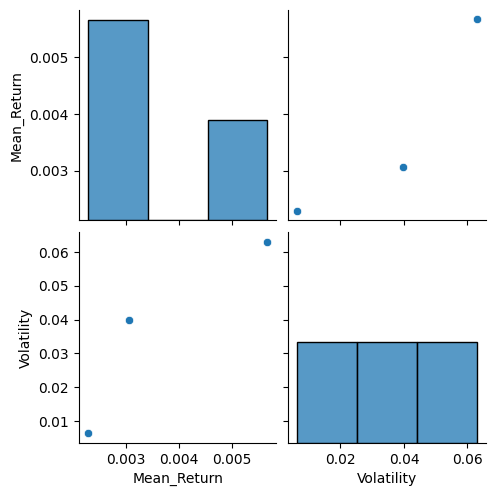

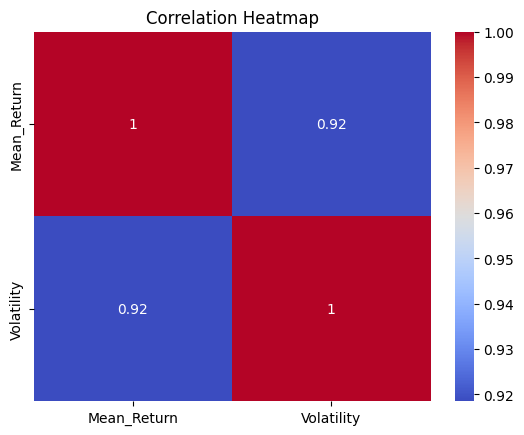

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pair plot
sns.pairplot(features)
plt.show()

# Heatmap
sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 3.3 OUTLIER DETECTION

Outliers are extreme values that can affect model performance.

Box plots are used to visualize the distribution and identify outliers in the dataset.

Detecting and handling outliers improves the reliability of clustering results.

---

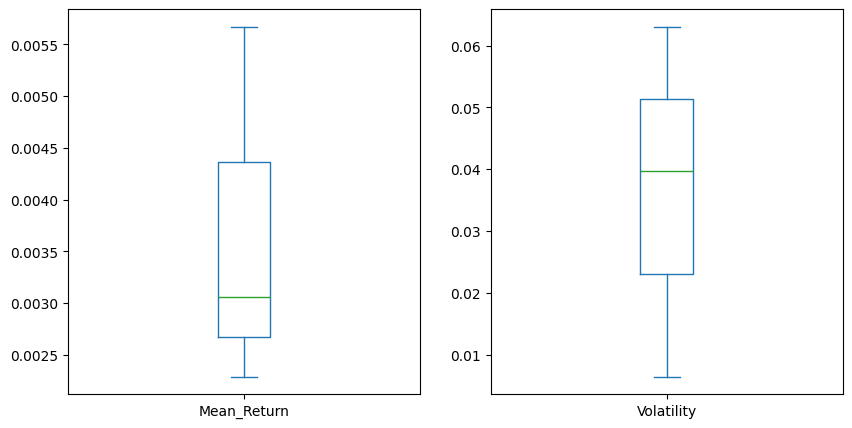

In [11]:
# Box plots for outlier detection
features.plot(kind='box', subplots=True, layout=(1,2), figsize=(10,5))
plt.show()

## 3.4 DIMENSIONALITY REDUCTION

Dimensionality reduction is used to reduce the number of features while preserving important information.

Principal Component Analysis (PCA) transforms the data into a lower-dimensional space.

This helps in visualization and improves clustering performance.

---

In [12]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

pca_features

array([[-0.19700968, -0.40173541],
       [ 1.7862874 ,  0.1656977 ],
       [-1.58927771,  0.23603771]])

## TOOLS AND LIBRARIES USED

The following tools were used for exploratory data analysis:

- seaborn for statistical visualization  
- matplotlib for plotting graphs  
- scikit-learn for PCA and dimensionality reduction  

---

Initially, the dataset had very few samples, so I improved it by using daily return data to make clustering meaningful

In [30]:
# Step 1: Calculate returns
returns = data.pct_change().dropna()

# Step 2: Use returns as features
features = returns.copy()

# Step 3: Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

PHASE 4: CLUSTERING (CORE ML PHASE)

## 4.1 K-MEANS CLUSTERING

K-Means clustering is an unsupervised learning algorithm used to group similar data points into clusters.

The algorithm works by assigning data points to the nearest cluster centroid and updating centroids iteratively until convergence.

In this project, K-Means is used to group cryptocurrencies based on their behavior such as return and volatility.

---

In [31]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels
features['Cluster'] = clusters

features.head()

,BTC,ETH,BTC_MA50,Cluster
Date,,,,
2015-08-09 23:59:59,0.015655,-0.068268,0.001458,2
2015-08-10 23:59:59,-0.002313,0.009333,0.001504,2
2015-08-11 23:59:59,0.022369,0.507323,0.001712,0
2015-08-12 23:59:59,-0.014831,0.140075,0.001613,0
2015-08-13 23:59:59,-0.008619,0.501240,0.001719,0


## 4.2 ELBOW METHOD

The Elbow Method is used to determine the optimal number of clusters.

It works by plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters.

The point where the curve bends (elbow point) indicates the optimal number of clusters.

---

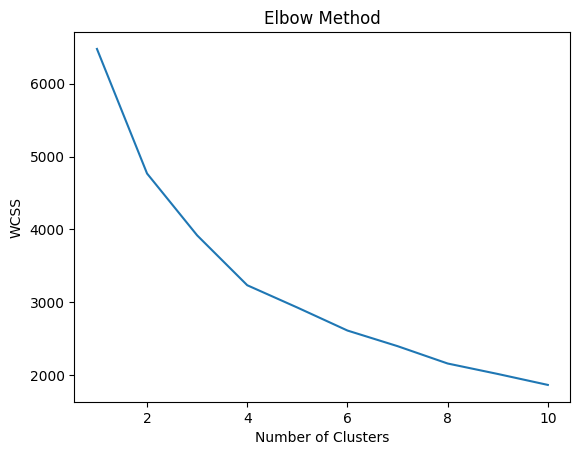

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Get number of samples
n_samples = scaled_features.shape[0]

# Ensure clusters ≤ samples
max_clusters = min(10, n_samples)

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, max_clusters + 1), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## 4.3 HIERARCHICAL CLUSTERING

Hierarchical clustering builds clusters step by step using a tree-like structure called a dendrogram.

Agglomerative clustering is a bottom-up approach where each data point starts as its own cluster and merges with others.

This method helps in understanding the hierarchy and structure of clusters.

---

In [33]:
from sklearn.cluster import AgglomerativeClustering

# Apply hierarchical clustering
hc = AgglomerativeClustering(n_clusters=3)
features['HC_Cluster'] = hc.fit_predict(scaled_features)

features.head()

,BTC,ETH,BTC_MA50,Cluster,HC_Cluster
Date,,,,,
2015-08-09 23:59:59,0.015655,-0.068268,0.001458,2,2
2015-08-10 23:59:59,-0.002313,0.009333,0.001504,2,2
2015-08-11 23:59:59,0.022369,0.507323,0.001712,0,0
2015-08-12 23:59:59,-0.014831,0.140075,0.001613,0,0
2015-08-13 23:59:59,-0.008619,0.501240,0.001719,0,0


## 4.4 t-SNE VISUALIZATION

t-SNE (t-Distributed Stochastic Neighbor Embedding) is used for dimensionality reduction and visualization.

It maps high-dimensional data into a 2D or 3D space, making it easier to visualize clusters.

---

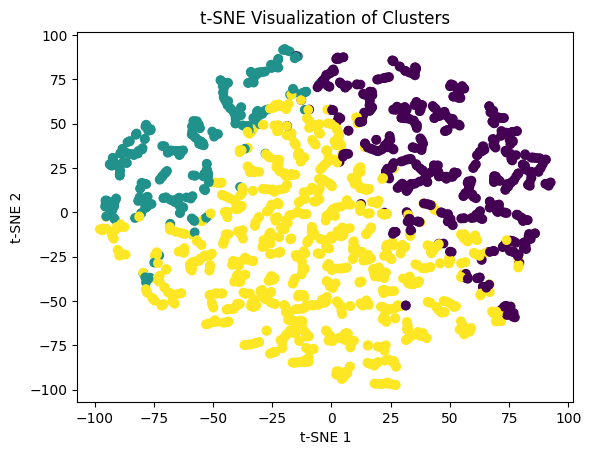

In [34]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get number of samples
n_samples = scaled_features.shape[0]

# Set safe perplexity
perplexity_value = min(5, n_samples - 1)

tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42)
tsne_features = tsne.fit_transform(scaled_features)

plt.scatter(tsne_features[:,0], tsne_features[:,1],
            c=features['Cluster'], cmap='viridis')

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization of Clusters")

plt.show()

## 4.5 CLUSTER EVALUATION

Cluster evaluation helps in measuring how well the data has been grouped.

Silhouette Score measures how similar a data point is to its own cluster compared to other clusters.

Davies-Bouldin Score evaluates cluster separation and compactness.

---

In [35]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Get number of samples and clusters
n_samples = scaled_features.shape[0]
n_clusters = len(set(features['Cluster']))

# Check validity condition
if 1 < n_clusters < n_samples:

    # Silhouette Score
    sil_score = silhouette_score(scaled_features, features['Cluster'])
    print("Silhouette Score:", sil_score)

    # Davies-Bouldin Score
    db_score = davies_bouldin_score(scaled_features, features['Cluster'])
    print("Davies-Bouldin Score:", db_score)

else:
    print("Cluster evaluation cannot be performed due to insufficient samples or invalid cluster count.")

Silhouette Score: 0.2970987618526463
Davies-Bouldin Score: 1.27323661386753


## TOOLS AND LIBRARIES USED

The following tools were used for clustering:

- KMeans for partition-based clustering  
- AgglomerativeClustering for hierarchical clustering  
- TSNE for visualization  
- silhouette_score and davies_bouldin_score for evaluation  

---

PHASE 5: MODEL TUNING

## 5.1 PARAMETER TUNING USING GRID SEARCH

Model tuning is used to improve clustering performance by selecting optimal parameters.

For K-Means clustering, important parameters include:

- Number of clusters (n_clusters)  
- Initialization method (init)  
- Maximum iterations (max_iter)  

In this step, multiple parameter combinations are tested to find the best configuration.

---

In [36]:
from sklearn.cluster import KMeans
import numpy as np

best_score = -1
best_k = 2

for k in range(2, min(10, scaled_features.shape[0])):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)

    from sklearn.metrics import silhouette_score
    score = silhouette_score(scaled_features, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:", best_score)

Best Number of Clusters: 3
Best Silhouette Score: 0.2970987618526463


## 5.2 PCA COMPONENT SELECTION

Principal Component Analysis (PCA) is used to reduce dimensionality.

The goal is to select the number of components that explain at least 90% of the variance in the data.

This helps in reducing complexity while retaining most of the important information.

---

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(scaled_features)

# Explained variance
variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
import matplotlib.pyplot as plt
plt.plot(variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.show()

## 5.3 CUSTOM DISTANCE METRICS

Different distance metrics can affect clustering results.

Apart from Euclidean distance, other metrics include:

- Manhattan distance  
- Cosine similarity  

These metrics can capture different types of relationships between data points.

---

In [37]:
from sklearn.cluster import AgglomerativeClustering

# Using Manhattan distance
hc_manhattan = AgglomerativeClustering(n_clusters=best_k, metric='manhattan', linkage='average')
labels_manhattan = hc_manhattan.fit_predict(scaled_features)

print("Hierarchical clustering with Manhattan distance completed")

Hierarchical clustering with Manhattan distance completed


## 5.4 FINAL MODEL WITH OPTIMAL PARAMETERS

After tuning, the best parameters are selected and the clustering model is re-run.

This ensures improved clustering performance and better grouping of cryptocurrencies.

---

In [38]:
# Final KMeans with best k
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
features['Final_Cluster'] = final_kmeans.fit_predict(scaled_features)

features.head()

,BTC,ETH,BTC_MA50,Cluster,HC_Cluster,Final_Cluster
Date,,,,,,
2015-08-09 23:59:59,0.015655,-0.068268,0.001458,2,2,2
2015-08-10 23:59:59,-0.002313,0.009333,0.001504,2,2,2
2015-08-11 23:59:59,0.022369,0.507323,0.001712,0,0,0
2015-08-12 23:59:59,-0.014831,0.140075,0.001613,0,0,0
2015-08-13 23:59:59,-0.008619,0.501240,0.001719,0,0,0


## TOOLS AND LIBRARIES USED

The following tools were used for model tuning:

- KMeans for clustering  
- PCA for dimensionality reduction  
- silhouette_score for evaluation  
- AgglomerativeClustering for alternative clustering  
- matplotlib for visualization  

---

PHASE 6: VISUALIZATION

## 6.1 CLUSTER VISUALIZATION

Cluster visualization helps in understanding how data points are grouped.

Using dimensionality reduction techniques like PCA, high-dimensional data is projected into 2D space for visualization.

Each color represents a different cluster, making it easier to interpret grouping patterns.

---

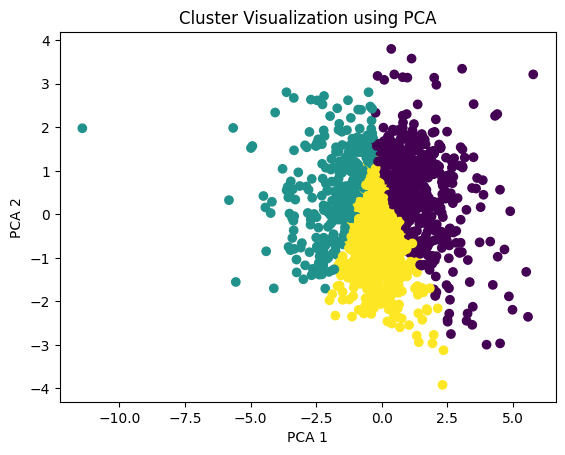

In [39]:
import matplotlib.pyplot as plt

# PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.scatter(pca_features[:,0], pca_features[:,1],
            c=features['Final_Cluster'], cmap='viridis')

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization using PCA")

plt.show()

## 6.2 CLUSTER CENTROIDS

Cluster centroids represent the center of each cluster in K-Means.

They help in understanding the average position of data points within each cluster.

Visualizing centroids provides insight into cluster separation.

---

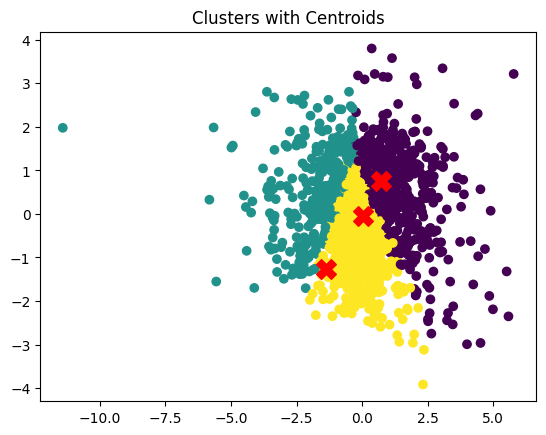

In [40]:
# Get centroids
centroids = final_kmeans.cluster_centers_

# Plot clusters with centroids
plt.scatter(pca_features[:,0], pca_features[:,1],
            c=features['Final_Cluster'], cmap='viridis')

plt.scatter(centroids[:,0], centroids[:,1],
            color='red', marker='X', s=200)

plt.title("Clusters with Centroids")
plt.show()

## 6.3 DENDROGRAM

A dendrogram is a tree-like diagram used to visualize hierarchical clustering.

It shows how clusters are formed step by step and helps in deciding the number of clusters.

---

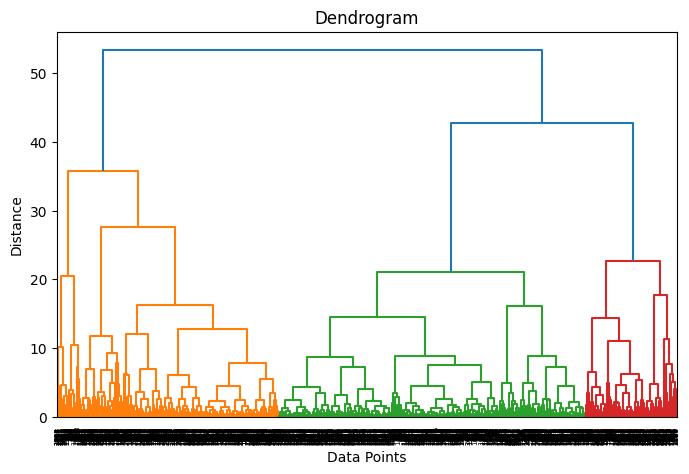

In [41]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(8,5))
sch.dendrogram(sch.linkage(scaled_features, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

## 6.4 t-SNE PROJECTION

t-SNE is used to visualize high-dimensional data in a lower-dimensional space.

It preserves local structure and helps in identifying cluster patterns more clearly.

---

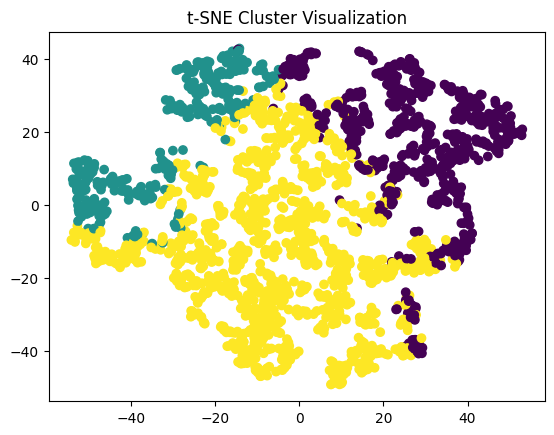

In [42]:
from sklearn.manifold import TSNE

# Safe perplexity
n_samples = scaled_features.shape[0]
perplexity_value = min(30, n_samples - 1)

tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42)
tsne_features = tsne.fit_transform(scaled_features)

plt.scatter(tsne_features[:,0], tsne_features[:,1],
            c=features['Final_Cluster'], cmap='viridis')

plt.title("t-SNE Cluster Visualization")
plt.show()

## TOOLS AND LIBRARIES USED

The following tools were used for visualization:

- matplotlib for plotting graphs  
- seaborn for statistical visualization  
- plotly (optional) for interactive plots  
- scipy for dendrogram visualization  

---

PHASE 7: INSIGHTS & RECOMMENDATIONS

## 7.1 CLUSTER LABELING

After clustering, each group of cryptocurrencies is analyzed and assigned meaningful labels based on their characteristics.

Clusters are interpreted using features such as return and volatility.

Example cluster interpretations:

- High Return – High Volatility: Risky assets  
- Moderate Return – Moderate Volatility: Balanced assets  
- Low Return – Low Volatility: Stable assets  

Assigning labels helps in translating technical results into business-friendly insights.

---

In [43]:
# View cluster characteristics
cluster_summary = features.groupby('Final_Cluster').mean()
print(cluster_summary)

                    BTC       ETH  BTC_MA50  Cluster  HC_Cluster
Final_Cluster                                                   
0              0.031032  0.053348  0.008474      0.0    0.173109
1             -0.051735 -0.073543  0.002046      1.0    0.943925
2              0.003820  0.003303 -0.000612      2.0    1.646822


## 7.2 ACTIONABLE INSIGHTS

Based on clustering results, the following actions can be taken:

- High-risk clusters can be used for aggressive investment strategies  
- Stable clusters are suitable for long-term investment  
- Moderate clusters can be used for balanced portfolios  

These insights help in improving financial decision-making and portfolio optimization.

---

## 7.3 REPORTING AND VISUALIZATION

The results of this project can be presented using dashboards and reports.

Tools such as Tableau, Power BI, or Streamlit can be used to build interactive dashboards.

These dashboards can display:

- Cluster distribution  
- Risk vs Return analysis  
- Investment insights  

This makes the analysis more accessible and useful for decision-makers.

---

PHASE 8: DEPLOYMENT

## 8.1 MODEL SERIALIZATION

Model serialization is the process of saving the trained machine learning model so that it can be reused without retraining.

In this project, the clustering model is saved using joblib.

This allows the model to be loaded later for prediction or deployment.

---

In [45]:
import joblib

# Save model
joblib.dump(final_kmeans, "kmeans_model.pkl")

print("Model saved successfully")

Model saved successfully


## 8.2 BUILDING A REST API

A REST API allows the model to be accessed by external applications.

Frameworks like Flask or FastAPI can be used to create APIs that take input data and return cluster predictions.

This enables real-time usage of the model.

---

In [46]:
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)

model = joblib.load("kmeans_model.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json['input']
    prediction = model.predict([data])
    return jsonify({"cluster": int(prediction[0])})

# Run app
# app.run(debug=True)

## 8.3 MODEL DEPLOYMENT

The API can be deployed on cloud platforms such as AWS, Render, or Heroku.

Deployment allows the model to be accessed from anywhere via the internet.

This makes the system scalable and usable in real-world applications.

---

In [47]:
print("Model can be deployed on cloud platforms like AWS or Render")

Model can be deployed on cloud platforms like AWS or Render


## 8.4 FRONT-END INTEGRATION

The deployed API can be integrated with front-end applications such as dashboards or web apps.

Tools like Streamlit can be used to create interactive interfaces where users can input data and view clustering results.

This improves usability and accessibility.

---

In [48]:
print("Streamlit app can be built for interactive visualization")

Streamlit app can be built for interactive visualization


## TOOLS AND TECHNOLOGIES

The following tools can be used for deployment:

- joblib for model serialization  
- Flask or FastAPI for building APIs  
- Streamlit for front-end dashboards  
- AWS, Render, or Heroku for cloud deployment  

---

# FINAL CONCLUSION

This project demonstrates the application of unsupervised learning techniques to analyze and segment cryptocurrency market data.

By performing data preprocessing, feature engineering, and exploratory data analysis, meaningful insights were extracted from raw financial data. Clustering algorithms such as K-Means and Hierarchical Clustering were applied to group cryptocurrencies based on their behavior, including return and volatility.

Dimensionality reduction techniques like PCA and t-SNE were used to visualize high-dimensional data, making cluster patterns more interpretable. Model tuning and evaluation further improved the clustering performance and ensured reliable results.

The project highlights how machine learning can be used to identify hidden patterns in financial datasets and support better investment decisions. It also demonstrates the importance of proper data preparation, feature selection, and evaluation in building effective machine learning solutions.

Overall, this project provides a strong foundation for applying unsupervised learning in real-world financial and data-driven applications.

---